# An introduction to <i>geocontext</i> 
### Pontus Hennerdal, December 2022

This notebook can be used for importing a CSV-file (<i>points</i>) and calculating the geographical context around each point in that file. The geographical context is the k-nearest neighbours in another CSV-file (<i>popLocations</i>, could also be the same file). The calculation could be either be the proportion of the k-nearest neighbours being a part of a group or a weighted average and standard deviation for each point among the k-nearest neighbours.

Using the notion used in <i>Hennerdal & Nielsen (2017) http://dx.doi.org/10.1080/24694452.2016.1261685</i>: If $t(x_{i})$ is defined as the total number of inviduals in the location $x_{i}$, we can express the calculation made by this script as statistics calculated for every set $N_{j,k}$ of locations $x_{i}$ located within the distance $r_{j,k}$ from $x_{j}$.

$$N_{j,k} = \left\{x_{i} \in \mathbb{R}^{2} : | x_{i}-x_{j} | \leq r_{j,k} \right\}$$

When $r_{j,k}$ is the smallest possible but the the following criteria that the sum of individuals in the set of locations $N_{j,k}$ is the same or larger than the value $k$ is met.

$$k \leq \sum_{x_{i} \in N_{j,k}}t(x_{i})$$

This is the same as calculating statistics (e.g. proportion or average and standard deviation) among the k-nearest neighbours for a set of locations.

### Using this Jupyter Notebook
Use this Jupyter Notebook by <b>changing the names or values marked with CHANGE in the <i>Read files section</i></b> and preferable also in the <i>Saving the results as a CSV section</i>.

Run cell by pressing SHIFT and ENTER.

If using this script for a publication. Please refer to it as: <i>P. Hennerdal, geocontext (2022), GitHub repository, https://github.com/PonHen/geocontext</i>

# Importing libraries
This first step imports some external libraries needed to run the functions in this Jupyter Notebook.

In [39]:
# import sys
# !{sys.executable} -m pip install pandas numpy matplotlib


In [40]:
import pandas as pd # This library is used to handle data frames.
import math # This library including mathematical functions.
import numpy as np # This library including more mathematical functions.
import time # This library is used to measure the time to run the script.
import matplotlib.pyplot as plt # This library is used for plotting results.

In [41]:
# import sys
# !{sys.executable} -m pip install "sqlalchemy>=2" "psycopg[binary]>=3"


In [42]:
import pandas as pd

df = pd.read_csv(r"C:/gislab/data/tanum_h3r8_byggar_bins.csv")

points = df[["hex_id", "east", "north"]].copy()

# pick bin columns automatically
bin_cols = [c for c in df.columns if c.startswith("b")]

pop = df[["hex_id", "east", "north"] + bin_cols].copy()


points.head(), pop.head()



(            hex_id           east         north
 0  8808b49203fffff  291544.531600  6.490322e+06
 1  8808b49209fffff  290088.122142  6.489949e+06
 2  8808b4920bfffff  290729.830601  6.490495e+06
 3  8808b49215fffff  292186.193909  6.490869e+06
 4  8808b49219fffff  291198.490202  6.491762e+06,
             hex_id           east         north  b1900_1910  b1930  \
 0  8808b49203fffff  291544.531600  6.490322e+06           1      1   
 1  8808b49209fffff  290088.122142  6.489949e+06           0      1   
 2  8808b4920bfffff  290729.830601  6.490495e+06           1      3   
 3  8808b49215fffff  292186.193909  6.490869e+06           0      0   
 4  8808b49219fffff  291198.490202  6.491762e+06           0      1   
 
    b1801_1899  b1920  b2000  b1910  b1960  b1970  b1980  b2020  b1950  b1940  \
 0           0      0      0      0      0      0      0      0      0      0   
 1           1      1      1      0      0      0      0      0      0      0   
 2           1      1      1      

# Defining the <i>geocontext</i> function

## Factor analysis – restart point


In [43]:
def geocontext(points,
               popLocations,
               groups,
               populations,
               proportions,
               kValues,
               pointsNorth='North',
               pointsEast='East',
               popLocationsNorth='North',
               popLocationsEast='East'):
    """Calculates the geographical context for each point and return a DataFrame.
    
    This function calculate the geographical context around each point in 
    the pandas DataFrame points. The context is the proportion of the 
    population among the k-nearest neighbours in the pandas DataFrame 
    popLocations that is part of a group, if the values of the groups 
    represents the absoulte number of indivuduals being part of a group.
    However, if the values of the groups represents a value between 0 and 1,
    the context is the weighted average and standard deviation for the
    k-nearest neighbours. The distances is measured as the Euclidean distance.

    Keyword arguments:
    points            -- pandas DataFrame with coordinates
    popLocations      -- pandas DataFrame with coordinates, values and populations
    groups            -- list with strings naming the columns holding the values
    populations       -- list with strings naming the columns holding the populations
    proportions       -- list with booleans, True if calculate proportion and not average
    kValues           -- list with integers being the k in the k-nearest neighbours
    pointsNorth       -- string naming of the column (default 'North')
    pointsEast        -- string naming of the column (default 'East')
    popLocationsNorth -- string naming of the column (default 'North')
    popLocationsEast  -- string naming of the column (default 'East')
    """
    
    # Checking the format of the variables.
    if type(groups) != list: 
        raise TypeError('groups need to be a list with column names')
    
    if type(populations) == list:
        if len(populations) == 1:
            multi = False
        else:
            multi = True 
            if len(groups) != len(populations):
                raise IndexError('populations need to have the same length as groups')
    else:
        raise TypeError('populations need to be a column name or a list with column names')
          
    if type(kValues) != list: 
        raise TypeError('kValues need to be a list with k-values')
    
    # To make sure the k-values are listed ascending, the list with k-values 
    # is sorted.
    kValues.sort()
    
    # Creating space in the points for radius, total, and group 
    # count for every k-value.
    results = []
    
    # Creating space in the popLocations for distance to a point. 
    # This column will be changed for every point in points.
    popLocations['Distance'] = 0
    
    # For every point in points.
    for pointIndex, point in points.iterrows():
        result = {'pointIndex': pointIndex}
        
        # Calculate the Euclidean distance from the point to every populated 
        # location in popLocations.
        popLocations['Distance'] = np.sqrt(
            np.power(point[pointsNorth] - popLocations[popLocationsNorth], 2) 
            + np.power(point[pointsEast] - popLocations[popLocationsEast], 2)).astype('int')
        
        # Sort populated locations by distance to the point.
        popSorted = popLocations.sort_values('Distance')  # avoid in-place mutation 
        
        # For every column used to sum up to the k-value
        groupIndex = 0
        for pop_Column in populations:
            
            # Set start values for every point (and category of totals)
            radius_List = []
            population = 0 # This is the value that values will be added to until it is larger than k
            index = 0 # This index will relate to the populated locations sorted from nearest
            n = len(popSorted)   # <-- define n here
        
            # Going through every k-value in the list. 
            for kValue in kValues:
                #n = len(popLocations)

                
                # While the poplation is lower than the k-value
                while population < kValue and index < n:
                    # Add the population of that populated location
                    population += popSorted[pop_Column].iloc[index]   # <-- FIXED NAME
                    index += 1

                if population < kValue:
                    population = population  # keep max available    
                if index == 0:
                    radius = 0
                else:
                    radius = popSorted['Distance'].iloc[index - 1]
                radius_List.append(radius)
                if multi:
                    result[f'radius_{groups[groupIndex]}_k{kValue}'] = radius
                else:
                    result[f'radius_k{kValue}'] = radius

            # When the the max radius for all k-values are found: go through 
            # every k-value in the list again.
            for k_Index in range(len(kValues)):
                # For each k-value, select all populated locations upp to 
                # the previous found max distance.
                selection = popSorted[popSorted['Distance'] <= radius_List[k_Index]]
            
                # For each group, calculate the sum of that group among the 
                # selected nearest neighbours.
                if multi:
                    if proportions[groupIndex]:
                        result[
                            f'group_{groups[groupIndex]}_k{kValues[k_Index]}'
                        ] = selection[groups[groupIndex]].sum()
                    else:
                        average = np.average(selection[groups[groupIndex]], 
                                             weights=selection[pop_Column])
                        variance = np.average((selection[groups[groupIndex]] - average)**2, 
                                              weights=selection[pop_Column])
                        
                        result[
                            f'mean_{groups[groupIndex]}_k{kValues[k_Index]}'
                        ] = average
                        result[
                            f'std_{groups[groupIndex]}_k{kValues[k_Index]}'
                        ] = math.sqrt(variance)
                else:
                    for group in groups:
                        if proportions[groupIndex]:
                            result[
                                f'group_{group}_k{kValues[k_Index]}'
                            ] = selection[group].sum()
                        else:
                            average = np.average(selection[group], 
                                                 weights=selection[pop_Column])
                            variance = np.average((selection[group] - average)**2, 
                                                  weights=selection[pop_Column])
                            result[
                                f'mean_{group}_k{kValues[k_Index]}'
                            ] = average
                            result[
                                f'std_{group}_k{kValues[k_Index]}'
                            ] = math.sqrt(variance)
            
                # Calculate the sum of selected nearest neighbours
                if multi:
                    result[
                        f'total_{groups[groupIndex]}_k{kValues[k_Index]}'
                    ] = selection[pop_Column].sum() 
                else:
                    result[
                        'total_k'+str(kValues[k_Index])
                    ] = selection[pop_Column].sum() 
            
            groupIndex += 1
        results.append(result)
    
    points = pd.concat([points, pd.DataFrame(results).set_index('pointIndex')], axis=1)

    # Calculate the proportion those groups are of the total amount of 
    # neighbours. If statistics=True, also other statistics are 
    # calculated.
    for kValue in kValues:
        groupIndex = 0
        for group in groups:
            if proportions[groupIndex]:
                if multi:
                    points[f'mean_{group}_k{kValue}'] = points[
                        f'group_{group}_k{kValue}'] / points[f'total_{group}_k{kValue}']
                else:
                    points[f'mean_{group}_k{kValue}'] = points[
                        f'group_{group}_k{kValue}'] / points[f'total_k{kValue}']
            groupIndex += 1
    
    # The function returns points with the added columns.
      
    return points

# Read files (CHANGE)
### Read file with points
The cell below is reading a CSV-file with the points the context will be calculated around and save it as the pandas DataFrame <i>pointsNoContextDF</i>. The file need to be located in the same folder as the Jupyter Notebook and the code in the cell need to be changed to match the name of the CSV-file and the delimiter used in that file.
```python
pointsNoContextDF = pd.read_csv('FILE_NAME.csv', delimiter=',')
```
After running the cell you can see the column names and the first five rows. Find the names of the columns holding the coordinates for North and East respectivly. Change the code in the next cell to match the names of the columns.
```python
points_NorthColumnName = 'NAME_OF_COLUMN_NORTH'
points_EastColumnName = 'NAME_OF_COLUMN_EAST'
```

In [44]:
# Reads the file. The file should be saved in the same folder 
# as this jupyter notebook.
# pointsNoContextDF = pd.read_csv('CHANGE.csv', delimiter='CHANGE')

# print(f'There is {len(pointsNoContextDF)} rows, here is the first 5:')
# pointsNoContextDF.head()

# Instead of reading CSV, use the DataFrames we already created from Postgres
popLocationsDF = popLocationsDF.reset_index(drop=True)
pointsNoContextDF = pointsNoContextDF.reset_index(drop=True)


print(f"points rows: {len(pointsNoContextDF)}")
print(f"popLocations rows: {len(popLocationsNoContextDF)}")
pointsNoContextDF.head(), popLocationsNoContextDF.head()


points rows: 1133
popLocations rows: 1133


(            hex_id           east         north
 0  8808b49203fffff  291544.531600  6.490322e+06
 1  8808b49209fffff  290088.122142  6.489949e+06
 2  8808b4920bfffff  290729.830601  6.490495e+06
 3  8808b49215fffff  292186.193909  6.490869e+06
 4  8808b49219fffff  291198.490202  6.491762e+06,
             hex_id           east         north  b1900_1910  b1930  \
 0  8808b49203fffff  291544.531600  6.490322e+06           1      1   
 1  8808b49209fffff  290088.122142  6.489949e+06           0      1   
 2  8808b4920bfffff  290729.830601  6.490495e+06           1      3   
 3  8808b49215fffff  292186.193909  6.490869e+06           0      0   
 4  8808b49219fffff  291198.490202  6.491762e+06           0      1   
 
    b1801_1899  b1920  b2000  b1910  b1960  b1970  b1980  b2020  b1950  b1940  \
 0           0      0      0      0      0      0      0      0      0      0   
 1           1      1      1      0      0      0      0      0      0      0   
 2           1      1      1      

In [45]:
# pointsNorthName = 'CHANGE'
# pointsEastName = 'CHANGE'

pointsNorthName = 'north'
pointsEastName  = 'east'

popLocationsNorthName = 'north'
popLocationsEastName  = 'east'


### Read file with populated locations
The cell below is reading a CSV-file with the the populated locations that constitutes the context and save it as the pandas DataFrame <i>popLocationsDF</i>. The file need to be located in the same folder as the Jupyter Notebook and the code in the cell need to be changed to match the name of the CSV-file and the delimiter used in that file.
```python
popLocationsDF = pd.read_csv('FILE_NAME_OF_OUTPUT_FILE.csv', delimiter=',')
```

In [46]:
# Reads the file. The file should be saved in the same folder 
# as this jupyter notebook.
# popLocationsDF = pd.read_csv('CHANGE.csv', delimiter='CHANGE')

# print(f'There is {len(popLocationsDF)} rows, here is the first 5:')
# popLocationsDF.head()

# Instead of reading CSV, use the Postgres-loaded DataFrame
popLocationsDF = pop.copy()

print(f"There is {len(popLocationsDF)} rows, here is the first 5:")
popLocationsDF.head()


There is 1133 rows, here is the first 5:


,hex_id,east,north,b1900_1910,b1930,b1801_1899,b1920,b2000,b1910,b1960,b1970,b1980,b2020,b1950,b1940,b1990,b2010,b1800
0,8808b49203fffff,291544.531600,6.490322e+06,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,8808b49209fffff,290088.122142,6.489949e+06,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0
2,8808b4920bfffff,290729.830601,6.490495e+06,1,3,1,1,1,1,2,2,1,0,0,0,0,0,0
3,8808b49215fffff,292186.193909,6.490869e+06,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4,8808b49219fffff,291198.490202,6.491762e+06,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0


Look att the column names in the file with populated locations that can be seen above after reading the file. Below, list the groups you want to include in the calculation. For example:
```python
groupList = ['NAME_OF_COLUMN_CATEGORY1', 
             'NAME_OF_COLUMN_CATEGORY2', 
             'NAME_OF_COLUMN_CATEGORY3']
```
If there is only one column stating the total population for the populated location, vrite the name as a string in the list <i>populationList</i>
```python
populationList = ['NAME_OF_COLUMN_TOTAL_POPULATION']
```
If the total population differ between different groups (for example if the groups is for different years and the total population differ between different years), then make <i>populationList</i> a list with the column with the same length as <i>groupList</i> and with the column names for the coresponding total populations. 
```python
populationList = ['NAME_OF_COLUMN_TOTAL_POPULATION_CATEGORY1', 
                  'NAME_OF_COLUMN_TOTAL_POPULATION_CATEGORY2', 
                  'NAME_OF_COLUMN_TOTAL_POPULATION_CATEGORY3']
```
The calculation could be either be the proportion of the k-nearest neighbours being a part of a group or a weighted average and standard deviation for each point among the k-nearest neighbours. For each column this could be stated in <i>propList</i> that need to have the same length as <i>groupList</i>. <i>True</i> means proportion will be calculated and <i>False</i>  average and standard deviation.
```python
propList = [True, 
            True, 
            False]
```
Find the names of the columns holding the coordinates for North and East respectivly. Change the code in the next cell to match the names of the columns.
```python
popLocationsNorthName = 'NAME_OF_COLUMN_NORTH_COORDINATE'
popLocationsEastName = 'NAME_OF_COLUMN_EAST_COORDINATE'
```

In [47]:
groupList = bin_cols
populationList = bin_cols
propList = [False] * len(bin_cols)

popLocationsDF['total'] = popLocationsDF[bin_cols].sum(axis=1)



In [48]:
groupList = bin_cols
populationList = bin_cols
propList = [False] * len(bin_cols)

popLocationsDF['total'] = popLocationsDF[bin_cols].sum(axis=1)




popLocationsNorthName = 'north'
popLocationsEastName  = 'east'


The list of k-values contains the size of the context. If k=1000, statistics will be calculated for the 1000 nearest neighbours for every point in the python DataFrame <i>pointsNoContextDF</i>.
```python
kValueList = [1000, 10000] 
```

In [49]:
kValueList = [5, 10, 25, 50, 100]


In [50]:
# 1) Make sure total exists and is numeric
popLocationsDF["total"] = pd.to_numeric(popLocationsDF["total"], errors="coerce").fillna(0)

print("rows popLocationsDF:", len(popLocationsDF))
print("sum(total):", popLocationsDF["total"].sum())
print("min/max total:", popLocationsDF["total"].min(), popLocationsDF["total"].max())
print("zeros in total:", (popLocationsDF["total"] == 0).sum())


rows popLocationsDF: 1133
sum(total): 12604
min/max total: 1 363
zeros in total: 0


In [51]:
global_total = popLocationsDF["total"].sum()
min_self = popLocationsDF["total"].min()
max_reachable_excl_self = global_total - min_self   # worst case: point with smallest self
print(global_total, max_reachable_excl_self)


12604 12603


In [52]:
print("pointsNoContextDF rows:", len(pointsNoContextDF))
print("popLocationsDF rows:", len(popLocationsDF))

# if IDs exist (hex_id):
print("shared id fraction:",
      pointsNoContextDF["hex_id"].isin(popLocationsDF["hex_id"]).mean())

# ensure popLocationsDF has clean 0..n-1 index (important if code uses iloc with incrementing index)
popLocationsDF = popLocationsDF.reset_index(drop=True)


pointsNoContextDF rows: 1133
popLocationsDF rows: 1133
shared id fraction: 1.0


# The actual calculations
Use the above defined function to calculate geographical context around each point.

In [53]:
# Start the stopwatch.
time0 = time.time()

# The actual calculation of the geographical context.
pointsWithContext = geocontext(points=pointsNoContextDF,
                               popLocations=popLocationsDF, 
                               groups=groupList, 
                               populations=populationList,
                               proportions=propList,
                               kValues=kValueList,
                               pointsNorth=pointsNorthName,
                               pointsEast=pointsEastName,
                               popLocationsNorth=popLocationsNorthName,
                               popLocationsEast=popLocationsEastName)

# Print the time for the calulation.
print(f'{round(time.time() - time0)} seconds')

130 seconds


# Results

### Some statistics

In [77]:
pointsWithContext.describe(percentiles=[0.5]).transpose()

,count,mean,std,min,50%,max
east,1133.0,2.910062e+05,7802.172957,2.716210e+05,2.893951e+05,3.103225e+05
north,1133.0,6.511372e+06,11339.874148,6.488283e+06,6.512361e+06,6.533175e+06
radius_b1900_1910_k5,1133.0,1.213601e+03,696.345071,0.000000e+00,8.420000e+02,9.682000e+03
radius_b1900_1910_k10,1133.0,1.750972e+03,920.403532,0.000000e+00,1.499000e+03,1.029600e+04
radius_b1900_1910_k25,1133.0,2.727339e+03,1290.742359,0.000000e+00,2.520000e+03,1.080900e+04
...,...,...,...,...,...,...
std_b1800_k50,1133.0,2.838807e+00,0.000000,2.838807e+00,2.838807e+00,2.838807e+00
total_b1800_k50,1133.0,3.400000e+01,0.000000,3.400000e+01,3.400000e+01,3.400000e+01
mean_b1800_k100,1133.0,3.000000e+00,0.000000,3.000000e+00,3.000000e+00,3.000000e+00
std_b1800_k100,1133.0,2.838807e+00,0.000000,2.838807e+00,2.838807e+00,2.838807e+00


### The result as a table

In [78]:
pointsWithContext

,hex_id,east,north,radius_b1900_1910_k5,radius_b1900_1910_k10,radius_b1900_1910_k25,radius_b1900_1910_k50,radius_b1900_1910_k100,mean_b1900_1910_k5,std_b1900_1910_k5,...,total_b1800_k10,mean_b1800_k25,std_b1800_k25,total_b1800_k25,mean_b1800_k50,std_b1800_k50,total_b1800_k50,mean_b1800_k100,std_b1800_k100,total_b1800_k100
0,8808b49203fffff,291544.531600,6.490322e+06,1331,2221,3460,5269,7420,2.714286,1.484615,...,10,3.296296,3.076973,27,3.0,2.838807,34,3.0,2.838807,34
1,8808b49209fffff,290088.122142,6.489949e+06,1350,1685,2938,4559,7011,3.250000,0.968246,...,10,3.296296,3.076973,27,3.0,2.838807,34,3.0,2.838807,34
2,8808b4920bfffff,290729.830601,6.490495e+06,740,1665,2938,4581,7106,3.400000,1.200000,...,10,3.296296,3.076973,27,3.0,2.838807,34,3.0,2.838807,34
3,8808b49215fffff,292186.193909,6.490869e+06,1503,1987,3340,4996,7399,1.400000,0.489898,...,10,3.296296,3.076973,27,3.0,2.838807,34,3.0,2.838807,34
4,8808b49219fffff,291198.490202,6.491762e+06,842,1350,2498,4250,6322,2.777778,1.133115,...,10,3.296296,3.076973,27,3.0,2.838807,34,3.0,2.838807,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,88099bcd21fffff,282410.724119,6.528342e+06,1974,2282,3320,4230,5806,2.000000,1.000000,...,14,3.560000,3.112298,25,3.0,2.838807,34,3.0,2.838807,34
1129,88099bcd23fffff,283050.423591,6.528886e+06,1497,2205,3693,4576,6242,1.400000,0.489898,...,15,3.560000,3.112298,25,3.0,2.838807,34,3.0,2.838807,34
1130,88099bcd27fffff,283222.098313,6.528171e+06,1470,1678,3317,4124,5876,1.857143,0.989743,...,15,3.560000,3.112298,25,3.0,2.838807,34,3.0,2.838807,34
1131,88099bcd2dfffff,281770.982840,6.527799e+06,1995,1995,2685,4028,5296,5.200000,2.749545,...,14,3.560000,3.112298,25,3.0,2.838807,34,3.0,2.838807,34


### Plotting the result
As default, the plot will show the first group with the largest k-value. 

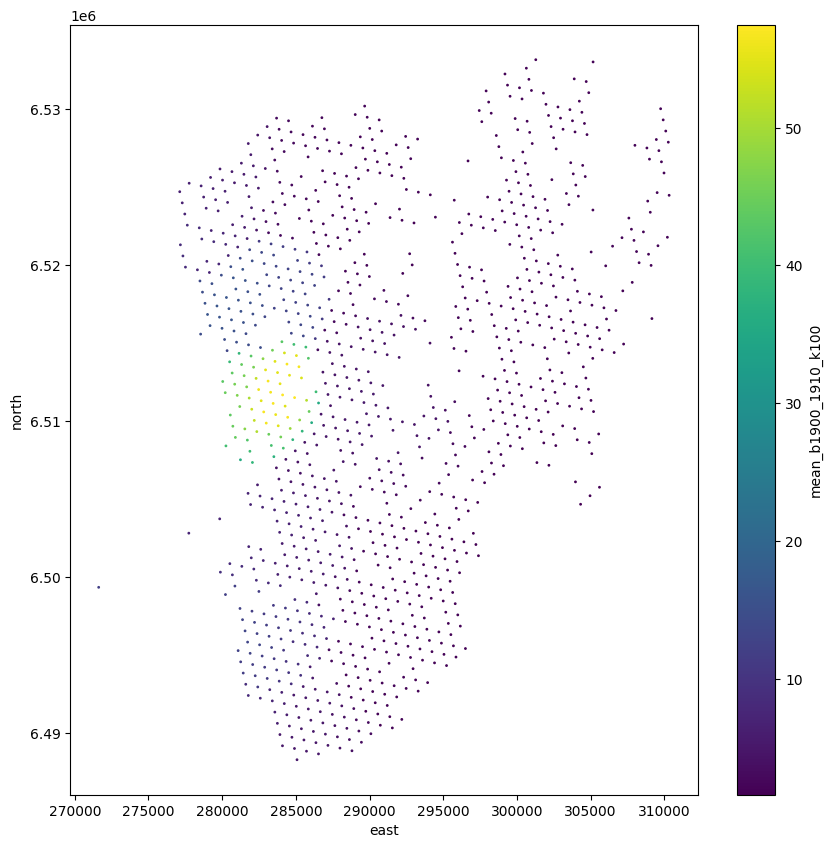

In [79]:
plotWidth = 1.5 + (10 
                   * (pointsWithContext[pointsEastName].max() 
                      - pointsWithContext[pointsEastName].min()) 
                   / (pointsWithContext[pointsNorthName].max() 
                      - pointsWithContext[pointsNorthName].min()))

plt.rcParams['figure.figsize'] = [plotWidth, 10]

pointsWithContext.plot.scatter(x=pointsEastName, 
                               y=pointsNorthName, 
                               c=f'mean_{groupList[0]}_k{kValueList[-1]}', 
                               colormap='viridis', s=1);

# Saving the results as a CSV (CHANGE)
The file with the results will be saved as a CSV-file in the same folder as the Jupyter Notebook. Change the name of the file in the code below.
```python
pointsWithContext.to_csv('FILE_NAME_OF_OUTPUT_FILE.csv')
```

In [57]:
# pointsWithContext.to_csv('CHANGE.csv')

pointsWithContext.to_csv('C:/gislab/vscode/geocontext/tanum_points_with_context.csv', index=False)


Faktor analys

In [58]:
import pandas as pd

X = pointsWithContext.filter(
    regex=r'^(mean_|std_)'
).copy()

X.shape


(1133, 150)

Add a temporary install cell at the top of the notebook and run it:

In [59]:
# %pip install scikit-learn factor-analyzer


In [60]:
# import sys
# !{sys.executable} -m pip install --user --upgrade --force-reinstall \
#  numpy==1.26.4 scipy==1.11.4 scikit-learn==1.3.2 factor-analyzer==0.5.1


In [61]:
import numpy, scipy, sklearn
import factor_analyzer
import importlib.metadata as im

numpy.__version__, scipy.__version__, sklearn.__version__, im.version("factor-analyzer")


('1.26.4', '1.17.0', '1.3.2', '0.5.1')

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xz = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)


In [63]:
Xz.mean().abs().max()


4.68469041141037e-15

In [64]:
Xz.std().round(2).value_counts()


1.0    146
0.0      4
Name: count, dtype: int64

In [65]:
import numpy as np
import pandas as pd

# 1) Kolla vilka kolumner som har 0-varians eller NaN/Inf
bad_zero = Xz.columns[Xz.std(ddof=0) == 0].tolist()
bad_nan  = Xz.columns[~np.isfinite(Xz.to_numpy()).all(axis=0)].tolist()

bad = sorted(set(bad_zero + bad_nan))
bad_zero, bad_nan, bad


(['mean_b1800_k50', 'std_b1800_k50', 'mean_b1800_k100', 'std_b1800_k100'],
 [],
 ['mean_b1800_k100', 'mean_b1800_k50', 'std_b1800_k100', 'std_b1800_k50'])

In [66]:
pointsWithContext[bad].describe().T


,count,mean,std,min,25%,50%,75%,max
mean_b1800_k100,1133.0,3.000000,0.0,3.000000,3.000000,3.000000,3.000000,3.000000
mean_b1800_k50,1133.0,3.000000,0.0,3.000000,3.000000,3.000000,3.000000,3.000000
std_b1800_k100,1133.0,2.838807,0.0,2.838807,2.838807,2.838807,2.838807,2.838807
std_b1800_k50,1133.0,2.838807,0.0,2.838807,2.838807,2.838807,2.838807,2.838807


Step 1: Eigenvalues (how many factors does the landscape want?)

In [67]:
import numpy as np
import pandas as pd

Xz_ok = Xz.drop(columns=bad)

R = np.corrcoef(Xz_ok, rowvar=False)

# sanity: inga NaN/Inf i R
assert np.isfinite(R).all()

eigvals, eigvecs = np.linalg.eig(R)
eig = (pd.Series(eigvals).sort_values(ascending=False).reset_index(drop=True))
eig



0      52.211692
1       9.343785
2       7.476195
3       6.822145
4       5.305584
         ...    
141     0.002944
142     0.002584
143     0.001889
144     0.001768
145     0.001549
Length: 146, dtype: float64

Then add the classic scree plot:

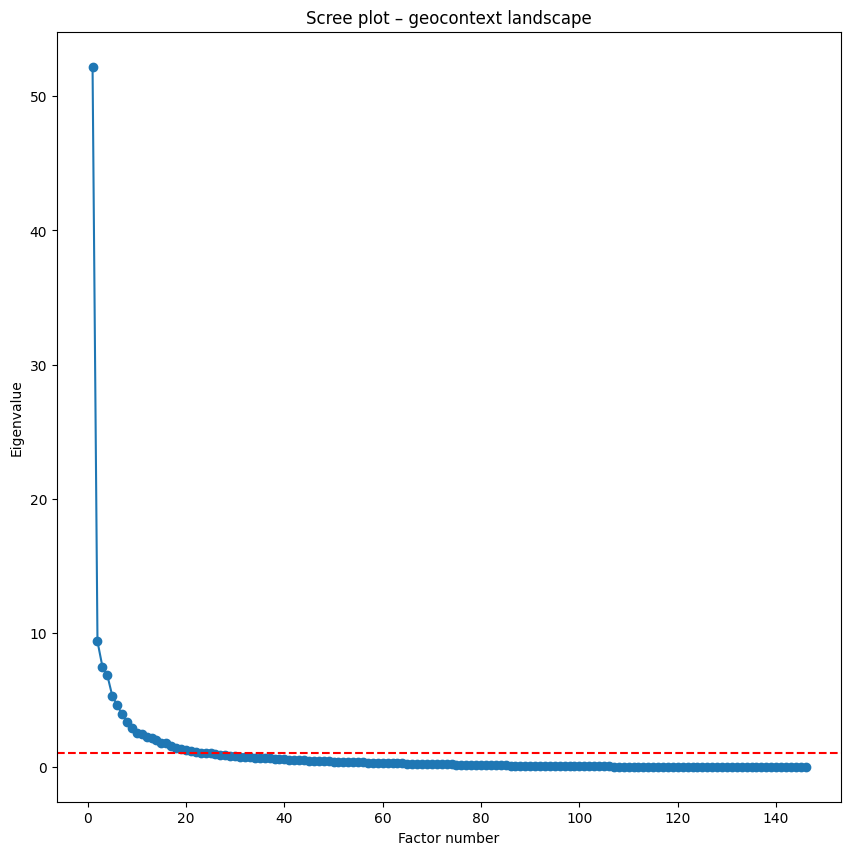

In [68]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(eig)+1), eig, marker='o')
plt.axhline(1, color='red', linestyle='--')  # Kaiser criterion
plt.xlabel("Factor number")
plt.ylabel("Eigenvalue")
plt.title("Scree plot – geocontext landscape")
plt.show()


In [69]:
# import sys
# !{sys.executable} -m pip install -U "scikit-learn<1.4" "factor-analyzer>=0.5,<0.6"


In [70]:
#import sys

# Force compatible versions into your user site-packages (avoids "Access is denied")
#!{sys.executable} -m pip install --user --upgrade --force-reinstall "scikit-learn==1.2.2" "factor-analyzer==0.5.1"


In [71]:
import numpy, scipy, sklearn
import importlib.metadata as im
numpy.__version__, scipy.__version__, sklearn.__version__, im.version("factor-analyzer")



('1.26.4', '1.17.0', '1.3.2', '0.5.1')

In [72]:
import numpy as np
import pandas as pd

# 1) Hitta problemkolumner
zero_var = Xz.columns[Xz.std(ddof=0) == 0]
nonfinite = Xz.columns[~np.isfinite(Xz.to_numpy()).all(axis=0)]

bad = sorted(set(zero_var.tolist() + nonfinite.tolist()))
bad


['mean_b1800_k100', 'mean_b1800_k50', 'std_b1800_k100', 'std_b1800_k50']

In [73]:
Xz_ok = Xz.drop(columns=bad).copy()
Xz_ok.shape


(1133, 146)

In [74]:
from factor_analyzer import FactorAnalyzer

n_factors = 5
fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax", method="principal")
fa.fit(Xz_ok)


loadings = pd.DataFrame(
    fa.loadings_,
    index=Xz_ok.columns,
    columns=[f"F{i+1}" for i in range(n_factors)]
)

loadings



,F1,F2,F3,F4,F5
mean_b1900_1910_k5,0.086796,0.092014,0.623343,0.194398,-0.029571
std_b1900_1910_k5,0.046149,0.078414,0.478468,0.215076,0.001843
mean_b1900_1910_k10,0.124991,0.145220,0.718326,0.160813,0.005545
std_b1900_1910_k10,0.102651,0.124965,0.570974,0.212385,0.042739
mean_b1900_1910_k25,0.344441,0.255002,0.714355,0.017500,0.106878
...,...,...,...,...,...
std_b1800_k5,0.091640,0.387012,-0.169020,0.499203,0.223219
mean_b1800_k10,0.204535,0.785437,-0.054928,0.295163,-0.130761
std_b1800_k10,-0.080101,0.729071,-0.113147,0.149398,-0.283543
mean_b1800_k25,0.065807,0.746720,-0.017601,0.155525,-0.244888


In [75]:
loadings.abs().sort_values("F1", ascending=False)


,F1,F2,F3,F4,F5
mean_b1980_k100,0.837257,0.022732,0.132715,0.180000,0.129462
mean_b1980_k50,0.816044,0.007838,0.149696,0.091860,0.094274
mean_b1801_1899_k50,0.812044,0.235630,0.173019,0.075771,0.331105
mean_b1900_1910_k100,0.805322,0.299395,0.296324,0.041198,0.235644
mean_b1920_k50,0.795182,0.025581,0.225733,0.183584,0.317354
...,...,...,...,...,...
mean_b1960_k5,0.028152,0.092535,0.402543,0.291168,0.352051
mean_b1960_k10,0.023902,0.112413,0.394500,0.255771,0.512779
std_b1990_k10,0.019977,0.467142,0.275429,0.044547,0.234888
std_b1960_k5,0.018286,0.054045,0.245648,0.114102,0.365007


In [81]:
import numpy as np
import pandas as pd

# 1) Replace inf with NaN
Xz_clean = Xz.replace([np.inf, -np.inf], np.nan)

# 2) Drop columns that are all NaN
Xz_clean = Xz_clean.dropna(axis=1, how="all")

# 3) Drop columns with zero variance (std == 0)
std = Xz_clean.std(axis=0, ddof=0)
Xz_clean = Xz_clean.loc[:, std > 0]

# 4) Drop rows with any remaining NaNs (or fill them, but dropping is safer)
Xz_clean = Xz_clean.dropna(axis=0, how="any")

print("Xz original:", Xz.shape)
print("Xz cleaned :", Xz_clean.shape)
print("Any NaN left?", Xz_clean.isna().any().any())
print("Any Inf left?", np.isinf(Xz_clean.to_numpy()).any())


Xz original: (1133, 150)
Xz cleaned : (1133, 146)
Any NaN left? False
Any Inf left? False


In [83]:
from factor_analyzer import FactorAnalyzer

fa = FactorAnalyzer(n_factors=n_factors, rotation="varimax")
fa.fit(Xz_clean)

scores = pd.DataFrame(
    fa.transform(Xz_clean),
    index=Xz_clean.index,
    columns=[f"F{i+1}" for i in range(n_factors)]
)



scores.head()


,F1,F2,F3,F4,F5
0,-0.483524,-0.081903,-0.219668,-0.437186,-0.696540
1,-0.217503,0.081819,-0.379532,-0.394128,-0.902584
2,-0.419811,0.006072,-0.219929,-0.433239,-0.744728
3,-0.401516,-0.171625,-0.184532,-0.425489,-0.730642
4,-0.345770,-0.191230,-0.184742,-0.576265,-0.712818


In [84]:
pointsWithContext = pointsWithContext.join(scores, how="left")



In [85]:
scores.describe().T


,count,mean,std,min,25%,50%,75%,max
F1,1133.0,-5.017071e-17,1.004014,-2.278287,-0.390333,-0.234023,0.017506,6.346352
F2,1133.0,1.505121e-16,0.987492,-2.095833,-0.804898,-0.088753,0.459721,4.121027
F3,1133.0,-5.017071e-17,0.987703,-2.195170,-0.389979,-0.197654,0.154558,8.392538
F4,1133.0,-1.818688e-16,1.001878,-2.897099,-0.694246,-0.385148,0.582797,3.183767
F5,1133.0,1.505121e-16,0.999949,-2.453719,-0.874243,0.072071,0.640949,3.909336


In [86]:
scores.corr().round(2)


,F1,F2,F3,F4,F5
F1,1.00,-0.00,0.01,-0.02,-0.00
F2,-0.00,1.00,0.01,0.02,0.00
F3,0.01,0.01,1.00,-0.01,-0.00
F4,-0.02,0.02,-0.01,1.00,0.01
F5,-0.00,0.00,-0.00,0.01,1.00


In [87]:
loadings_abs = loadings.abs()

for f in loadings.columns:
    print("\n", f, "\n", "-"*40)
    display(loadings.loc[loadings_abs[f].sort_values(ascending=False).head(8).index, [f]].sort_values(by=f, ascending=False))



 F1 
 ----------------------------------------


,F1
mean_b1980_k100,0.837257
mean_b1980_k50,0.816044
mean_b1801_1899_k50,0.812044
mean_b1900_1910_k100,0.805322
mean_b1920_k50,0.795182
mean_b1801_1899_k25,0.789441
std_b1900_1910_k100,0.784854
std_b1920_k50,0.768750



 F2 
 ----------------------------------------


,F2
mean_b1990_k100,0.802103
std_b1990_k100,0.800073
mean_b1800_k10,0.785437
mean_b1800_k25,0.746720
std_b1800_k10,0.729071
std_b1990_k50,0.708775
mean_b1990_k50,0.708142
mean_b1990_k25,0.675438



 F3 
 ----------------------------------------


,F3
mean_b1920_k10,0.777304
mean_b1801_1899_k5,0.776852
mean_b1920_k5,0.733530
mean_b1900_1910_k10,0.718326
mean_b1900_1910_k25,0.714355
mean_b1801_1899_k10,0.694732
mean_b1940_k10,0.687493
mean_b1930_k10,0.670975



 F4 
 ----------------------------------------


,F4
mean_b1910_k25,0.790647
mean_b1910_k50,0.775829
mean_b1910_k10,0.753333
std_b1910_k25,0.752921
std_b1910_k50,0.712233
std_b1910_k10,0.688522
mean_b1910_k5,0.623628
mean_b1940_k100,0.612430



 F5 
 ----------------------------------------


,F5
mean_b1970_k100,0.690050
std_b1950_k25,0.689950
mean_b1970_k50,0.671689
mean_b1950_k25,0.612608
std_b1950_k50,0.605997
std_b1970_k50,0.601693
mean_b1950_k100,0.586586
std_b1930_k25,0.580140


In [88]:
pointsWithContext.filter(regex=r"^F\d$").head()


,F1,F2,F3,F4,F5
0,-0.483524,-0.081903,-0.219668,-0.437186,-0.696540
1,-0.217503,0.081819,-0.379532,-0.394128,-0.902584
2,-0.419811,0.006072,-0.219929,-0.433239,-0.744728
3,-0.401516,-0.171625,-0.184532,-0.425489,-0.730642
4,-0.345770,-0.191230,-0.184742,-0.576265,-0.712818


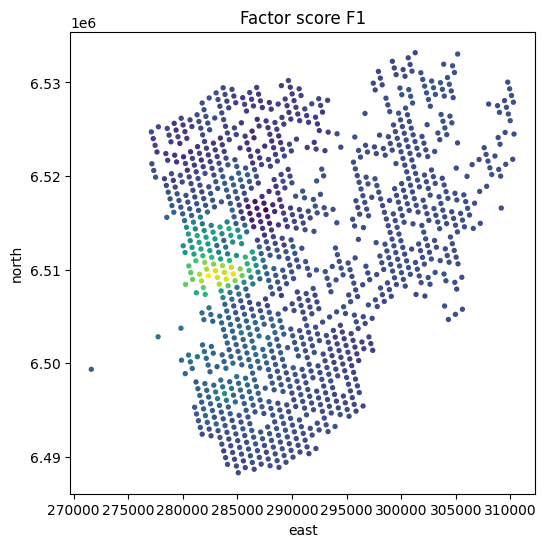

In [89]:
import matplotlib.pyplot as plt

f = "F1"  # try F2, F3...
plt.figure(figsize=(6,6))
plt.scatter(pointsWithContext["east"], pointsWithContext["north"], c=pointsWithContext[f], s=8)
plt.title(f"Factor score {f}")
plt.xlabel("east"); plt.ylabel("north")
plt.show()


In [ ]:
from sklearn.cluster import KMeans

K = 3   # start with 7 or 8 like your crime landscape
km = KMeans(n_clusters=K, n_init=50, random_state=42)

Fcols = [c for c in pointsWithContext.columns if c.startswith("F")]
pointsWithContext["class_km"] = km.fit_predict(pointsWithContext[Fcols])
pointsWithContext["class_km"].value_counts().sort_index()


C:\Users\henri\AppData\Local\Temp\ipykernel_26240\697013697.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pointsWithContext["class_km"] = km.fit_predict(pointsWithContext[Fcols])


class_km
0    192
1     85
2    275
3     52
4     52
5    346
6     11
7    120
Name: count, dtype: int64

In [91]:
profile = pointsWithContext.groupby("class_km")[Fcols].mean()
profile


,F1,F2,F3,F4,F5
class_km,,,,,
0,-0.380938,0.218518,-0.550010,0.537919,0.970916
1,0.409513,0.475296,1.350498,0.343153,-1.463363
2,-0.152567,0.392602,-0.228178,-0.378283,-1.060850
3,3.663240,0.102905,-0.867095,0.254279,0.633969
4,-0.439061,2.886933,0.174228,-0.355980,1.510635
5,-0.262512,-0.891857,-0.138663,-0.700001,0.230335
6,1.877998,0.109631,6.431828,-1.722445,2.526504
7,-0.143324,-0.320132,0.556791,1.983460,0.089139


In [92]:
profile.apply(lambda row: row.abs().sort_values(ascending=False).head(3), axis=1)


,F1,F2,F3,F4,F5
class_km,,,,,
0,NaN,NaN,0.550010,0.537919,0.970916
1,NaN,0.475296,1.350498,NaN,1.463363
2,NaN,0.392602,NaN,0.378283,1.060850
3,3.663240,NaN,0.867095,NaN,0.633969
4,0.439061,2.886933,NaN,NaN,1.510635
5,0.262512,0.891857,NaN,0.700001,NaN
6,1.877998,NaN,6.431828,NaN,2.526504
7,NaN,0.320132,0.556791,1.983460,NaN


In [93]:
loadings = pd.DataFrame(
    fa.loadings_,
    index=Xz_clean.columns,
    columns=[f"F{i+1}" for i in range(n_factors)]
)

loadings.abs().sort_values("F1", ascending=False).head(10)
loadings.abs().sort_values("F2", ascending=False).head(10)
loadings.abs().sort_values("F4", ascending=False).head(10)


,F1,F2,F3,F4,F5
mean_b1910_k25,0.176628,0.126144,0.146821,0.786018,0.099972
mean_b1910_k50,0.130412,0.191346,0.140624,0.773382,0.194408
std_b1910_k25,0.180968,0.135803,0.171359,0.744180,0.062494
mean_b1910_k10,0.173605,0.044402,0.284316,0.741703,0.057444
std_b1910_k50,0.069683,0.196894,0.150698,0.699522,0.140265
std_b1910_k10,0.268283,0.094836,0.289889,0.675634,0.103633
mean_b1940_k100,0.380720,0.520364,0.118975,0.614669,0.287272
mean_b1910_k5,0.147207,0.093340,0.275678,0.596720,0.126970
mean_b1910_k100,0.152246,0.366192,0.134802,0.593125,0.311342
std_b1940_k100,0.418896,0.490996,0.087947,0.541302,0.332849


In [94]:
pointsWithContext["recency_index"] = (
    pointsWithContext["mean_b2000_k50"] +
    pointsWithContext["mean_b2010_k50"]
) - (
    pointsWithContext["mean_b1910_k50"]
)



C:\Users\henri\AppData\Local\Temp\ipykernel_26240\945050013.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pointsWithContext["recency_index"] = (


In [95]:
loadings = pd.DataFrame(
    fa.loadings_,
    index=Xz_clean.columns,
    columns=[f"F{i+1}" for i in range(n_factors)]
)


In [96]:
for f in loadings.columns:
    print(f"\n=== {f} ===")
    display(
        loadings
        .assign(abs_val=loadings[f].abs())
        .sort_values("abs_val", ascending=False)
        [[f]]
        .head(10)
    )



=== F1 ===


,F1
mean_b1980_k100,0.835345
mean_b1801_1899_k50,0.812405
mean_b1980_k50,0.807884
mean_b1900_1910_k100,0.805133
mean_b1920_k50,0.796193
mean_b1801_1899_k25,0.788117
std_b1900_1910_k100,0.782601
std_b1920_k50,0.767805
std_b1801_1899_k25,0.760280
std_b1980_k100,0.735283



=== F2 ===


,F2
mean_b1970_k100,0.686638
std_b1950_k25,0.678811
mean_b1970_k50,0.661739
mean_b1950_k25,0.609549
std_b1950_k50,0.589937
std_b1970_k50,0.583924
mean_b1950_k100,0.578499
std_b1930_k25,0.566925
mean_b1970_k25,0.565381
mean_b1930_k100,0.564620



=== F3 ===


,F3
mean_b1920_k10,0.775842
mean_b1801_1899_k5,0.768351
mean_b1920_k5,0.719565
mean_b1900_1910_k25,0.712555
mean_b1900_1910_k10,0.700501
mean_b1801_1899_k10,0.698143
mean_b1940_k10,0.687545
mean_b1930_k10,0.664478
mean_b1940_k5,0.648901
mean_b1900_1910_k5,0.598108



=== F4 ===


,F4
mean_b1910_k25,0.786018
mean_b1910_k50,0.773382
std_b1910_k25,0.744180
mean_b1910_k10,0.741703
std_b1910_k50,0.699522
std_b1910_k10,0.675634
mean_b1940_k100,0.614669
mean_b1910_k5,0.596720
mean_b1910_k100,0.593125
std_b1940_k100,0.541302



=== F5 ===


,F5
mean_b1990_k100,0.803845
std_b1990_k100,0.801065
mean_b1800_k10,0.782369
mean_b1800_k25,0.733585
std_b1800_k10,0.715001
mean_b1990_k50,0.705025
std_b1990_k50,0.691180
mean_b1990_k25,0.657904
std_b1990_k25,0.564915
mean_b1990_k10,0.539648


In [ ]:
out = pointsWithContext[["hex_id"] + Fcols + ["class_km"]].copy()

# If you have geometry separately: join it in SQL (recommended)
out.to_sql("bornholm_r8_factors", engine, schema="h3", if_exists="replace", index=False)


-1

In [97]:
import os
os.getcwd()


'c:\\gislab\\vscode\\geocontext'

In [100]:
loadings_out = loadings.round(3).reset_index()
loadings_out.rename(columns={"index": "variable"}, inplace=True)

loadings_out.to_csv(
    "tanum_r8_factor_loadings.csv",
    index=False
)

pointsWithContext[["hex_id"] + Fcols + ["class_km"]].to_csv(
    "tanum_r8_factor_scores.csv",
    index=False
)


## User Information Management with Keyring

In [ ]:
import keyring
import getpass

# Setup keyring service information
SERVICE_NAME = "geocontext_app"

class UserManager:
    """Manage user credentials using keyring"""
    
    @staticmethod
    def store_credentials(username: str, password: str = None):
        """Store user credentials in keyring"""
        if password is None:
            password = getpass.getpass(f"Enter password for {username}: ")
        
        try:
            keyring.set_password(SERVICE_NAME, username, password)
            print(f"✓ Credentials stored for user: {username}")
            return True
        except Exception as e:
            print(f"✗ Error storing credentials: {e}")
            return False
    
    @staticmethod
    def get_credentials(username: str):
        """Retrieve user password from keyring"""
        try:
            password = keyring.get_password(SERVICE_NAME, username)
            if password:
                return password
            else:
                print(f"No credentials found for user: {username}")
                return None
        except Exception as e:
            print(f"✗ Error retrieving credentials: {e}")
            return None
    
    @staticmethod
    def update_credentials(username: str, new_password: str = None):
        """Update user password"""
        if new_password is None:
            new_password = getpass.getpass(f"Enter new password for {username}: ")
        
        return UserManager.store_credentials(username, new_password)
    
    @staticmethod
    def delete_credentials(username: str):
        """Delete user credentials from keyring"""
        try:
            keyring.delete_password(SERVICE_NAME, username)
            print(f"✓ Credentials deleted for user: {username}")
            return True
        except keyring.errors.PasswordDeleteError:
            print(f"No credentials found for user: {username}")
            return False
        except Exception as e:
            print(f"✗ Error deleting credentials: {e}")
            return False
    
    @staticmethod
    def list_stored_users():
        """List all stored users (if backend supports it)"""
        try:
            backend = keyring.get_keyring()
            print(f"Current keyring backend: {backend.__class__.__name__}")
            print(f"Service: {SERVICE_NAME}")
            print("Note: Some backends don't support listing credentials.")
        except Exception as e:
            print(f"✗ Error: {e}")

# Initialize manager
user_mgr = UserManager()

print("Keyring User Information System Initialized")
print(f"Service: {SERVICE_NAME}")
print(f"Keyring Backend: {keyring.get_keyring().__class__.__name__}")


Keyring User Information System Initialized
Service: geocontext_app
Keyring Backend: ChainerBackend


### Example Usage

In [ ]:
# Store a new user's credentials
username = "myuser"
password = "mypassword123"

# Store credentials
user_mgr.store_credentials(username, password)

# Retrieve credentials
retrieved_pass = user_mgr.get_credentials(username)
if retrieved_pass:
    print(f"Retrieved password for {username}: {'*' * len(retrieved_pass)}")

# Show keyring information
user_mgr.list_stored_users()


✓ Credentials stored for user: myuser
Retrieved password for myuser: *************
Current keyring backend: ChainerBackend
Service: geocontext_app
Note: Some backends don't support listing credentials.


### Change User Information

In [ ]:
# Update an existing user's password
username_to_update = "myuser"
new_password = "newpassword456"

# Option 1: Update with explicit password
user_mgr.update_credentials(username_to_update, new_password)

# Option 2: Interactive password prompt (uncomment to use)
# user_mgr.update_credentials(username_to_update)

# Verify the update
retrieved_new_pass = user_mgr.get_credentials(username_to_update)
if retrieved_new_pass == new_password:
    print(f"✓ Password successfully updated for {username_to_update}")
else:
    print(f"✗ Password update failed")

# Delete credentials if needed
# user_mgr.delete_credentials(username_to_update)


✓ Credentials stored for user: myuser
✓ Password successfully updated for myuser
